# Basic utils for Investing based on Indicators

## Imports

In [2]:
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt


import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import random
import plotly.express as px

# Attribution d'une graine.
random.seed(1)

torch.manual_seed(1)

%reload_ext autoreload
%autoreload 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Data reading and processing

In [3]:
data = pd.read_csv('data/binance/BTCUSDT_5m_Spot.csv', parse_dates=[0], index_col=0)

In [4]:

# Define the list of columns to compute
columns = [
    "%R",
    # Indicators That Need a Separate Window
    "RSI_7",
    "RSI_14",
    "RSI_28",
    "RSI_56",
    "MACD_26/12",
    "MACD_Signal_26/12/9",
    "MACD_50/200",
    
    # Indicators That Overlay on the Price Chart (with Close price subtracted)
    "SMA_50",
    "SMA_100",
    "SMA_200",
    "EMA_12",
    "EMA_26",
    "EMA_50",
    "EMA_200",
]



0.0006666561116299191


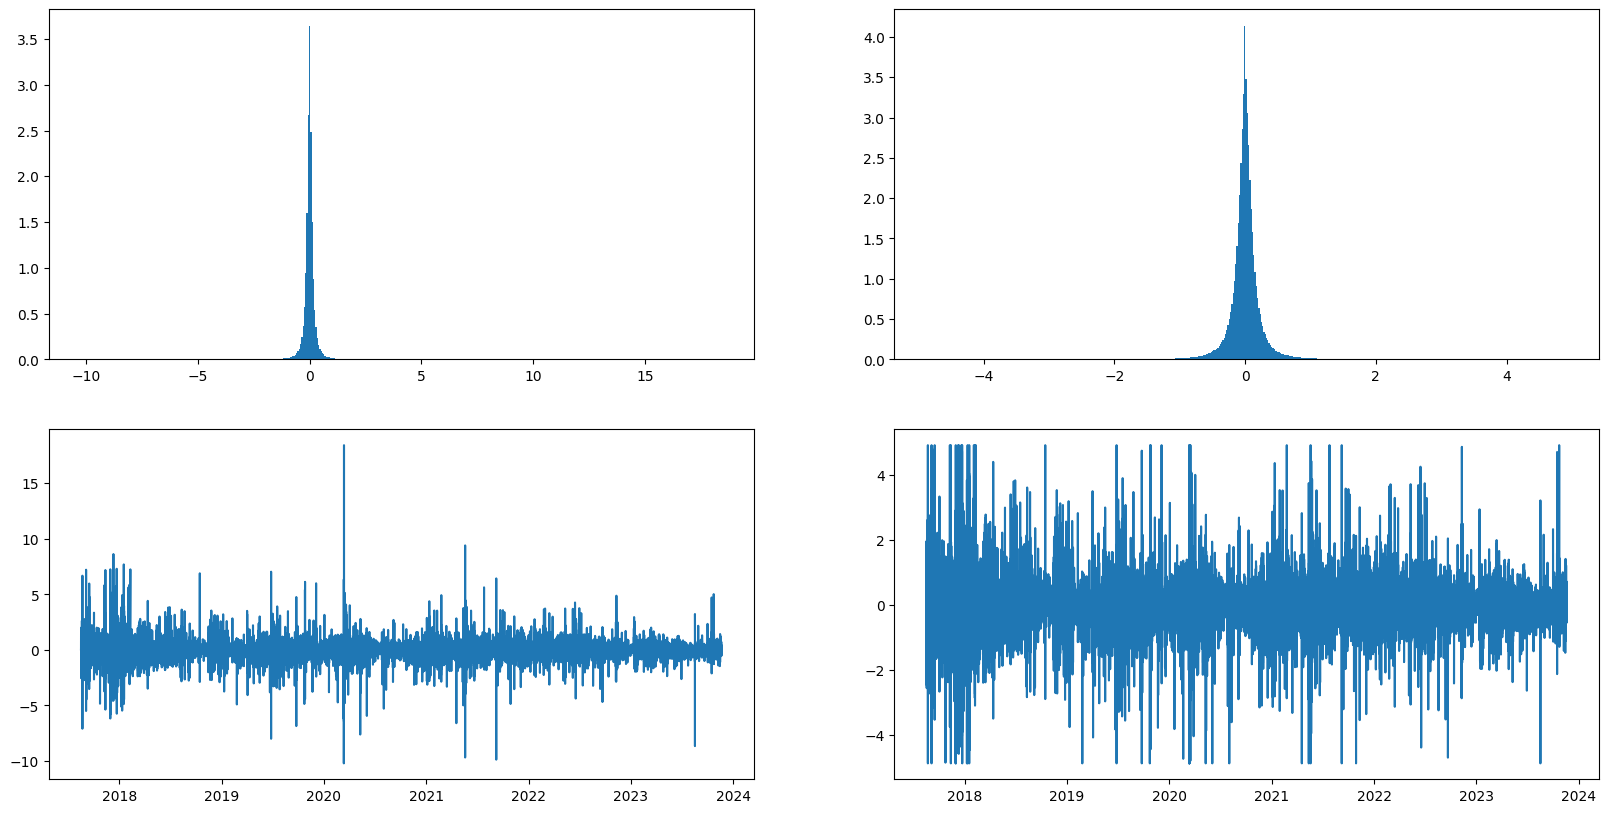

In [5]:
data.loc[:, '%R'] = data['Close'].pct_change()*100

df = data[['%R']].copy()

quatiles_threshold = 0.00005

plt.figure(figsize=(20, 10))

plt.subplot(2, 2, 1)    
plt.hist(df['%R'] , bins=500, density=True)

plt.subplot(2, 2, 3)
plt.plot(df['%R'])

df['%R'] = df['%R'].clip(lower=df['%R'].quantile(quatiles_threshold), upper=df['%R'].quantile(1-quatiles_threshold))

print(df['%R'].mean())

# df['%R'] = df['%R'] - df['%R'].mean()

plt.subplot(2, 2, 2)
plt.hist(df['%R'], bins=500, density=True)

plt.subplot(2, 2, 4)
plt.plot(df['%R'])

plt.show()

In [6]:
import ta


df.dropna(inplace=True)


In [7]:
df.describe()

,%R
count,656811.000000
mean,0.000667
std,0.263616
min,-4.875048
25%,-0.084076
50%,0.000000
75%,0.085670
max,4.923930


In [32]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

train_data, test_data = df[:int(len(data)*0.8)], df[int(len(data)*0.8):]

train_data = train_data.to_numpy()

test_data = test_data.to_numpy()

start_index = 0

train_target = train_data[:, :1]
train_target = train_target - train_target.mean()

test_target = test_data[:, :1]
test_target = test_target - test_target.mean() 

scaler = StandardScaler()


train_data = scaler.fit_transform(train_data[:, start_index:]) 
test_data = scaler.transform(test_data[:, start_index:])

In [33]:
def run_epoch(model, dataloader, optimizer, criterion):
    
    model.train()
    
    epoch_loss = 0

    batchs_number = len(dataloader)

    batchs = tqdm(enumerate(dataloader), unit='batch', total=batchs_number)
    for idx, (src, tgt_mask, tgt) in batchs:

        src = src.to(device)

        tgt = tgt.to(device)

        optimizer.zero_grad()

        out = model(src, tgt_mask.to(device))

        loss = criterion(out.contiguous(), tgt.contiguous())
        
        loss.backward()
        optimizer.step()
        epoch_loss += (loss.detach().item())

        if (idx + 5) % round(batchs_number/5) == 0:
            batchs.set_description('MSE {:.3E} '.format(
                epoch_loss/(idx+1)))

    return epoch_loss/batchs_number

In [34]:
def shift_sum(x):
    out = np.zeros((x.shape[0] + x.shape[1]-1))
    
    for k in range(x.shape[0]):
        out[k:k+x.shape[1]] += x[k]
        
    return out

In [35]:
torch2numpy = lambda x: x.cpu().detach().numpy()

def eval_epoch(model, dataloader, points=0):

    prediction = []
    targets = []
    returns = []
    
    with torch.no_grad():
        for idx, (src, tgt_mask, tgt) in enumerate(dataloader):
            pred = model(src.to(device), tgt_mask.to(device))
            prediction.append(torch2numpy(pred[...,0]))
            targets.append(torch2numpy(tgt[...,0]))

    prediction = np.concatenate(prediction, axis=0)
    targets = np.concatenate(targets, axis=0)
    
    # prediction = shift_sum(prediction)/prediction.shape[1]
    # targets = shift_sum(targets)/targets.shape[1]
    
    returns = prediction * targets
    
    norm = np.abs(np.diff(prediction, axis=0)).mean()
    normed_returns = returns/norm
    
    portfolio = np.cumsum(normed_returns)
    

    if points > 0:
        
        plt.figure(figsize=(14, 7))
        plt.subplot(2, 1, 1)
        plt.plot(targets[-points:], label='True')
        plt.plot(prediction[-points:], label='Prediction')
        plt.legend()
        plt.subplot(2, 1, 2)
        plt.plot(returns[-points:], label='Returns')
        plt.legend()
        plt.figure(figsize=(14, 7))
        plt.plot(portfolio, label='Portfolio')
        plt.show()

    return  normed_returns.mean(), norm, returns.mean()

In [36]:
class NN(nn.Module):
    def __init__(self, config):
        super(NN, self).__init__()
        self.input_size = config['input_size']
        self.pred_len = config['pred_len']
        self.hidden_size = config['hidden_size']
        
        self.linear1 = nn.Linear(self.input_size, self.hidden_size)
        self.linear2 = nn.Linear(self.hidden_size, self.hidden_size)
        self.linear3 = nn.Linear(self.hidden_size, self.pred_len)
        self.activation = nn.ReLU() #nn.Tanh()
        self.tanh = nn.Tanh()
        
        
    def forward(self, x, tgt_mask):
        
        x = self.linear1(x)
        x = self.activation(x)
        x = self.linear2(x)
        x = self.activation(x)
        x = self.linear3(x)

        return self.tanh(x)

In [37]:
config = {
    # data
 'seq_len': 29,
 'pred_len': 1,
 'batch_size': 32*8,
 'shuffle': True,
 'output_size': train_data.shape[1],
 'offset': 0,
 
    # model

 'model': NN,
 'input_size': train_data.shape[1],
 'hidden_size': 64,
 'num_layers': 2,
 'dropout': 0.0,
 'bidirectional': False,
 
 # Training
 
  'num_epochs': 10,
 'lr': 1e-4,
 'max_grad_norm': 0.1,
 'gamma': 0.2,
 'patience': 10,
 'cd': 0,
 }

class AttrDict(dict):
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

config = AttrDict(config)

In [38]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, data, target, seq_len, pred_len, offset):
        self.data = data
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.offset = offset
        
        self.target = target
        
        
        self.data = data[:-(offset+1)].astype(np.float32)
        
        self.target = target[1+offset:].astype(np.float32)
        
        
    def __len__(self):
        return len(self.data) - self.seq_len - self.pred_len - self.offset
    
    def __getitem__(self, idx):
        return self.data[idx],torch.zeros(1), self.target[idx]

In [39]:

from torch.utils.data import DataLoader

train_dataset = Dataset(train_data, target=train_target, seq_len=config.seq_len, pred_len=config.pred_len, offset=config.offset)

train_dataloader = DataLoader(
    train_dataset, config.batch_size, shuffle=config.shuffle, pin_memory=False)

train_dataloader_infer = DataLoader(
    train_dataset, config.batch_size, shuffle=False)

val_dataset = Dataset(test_data, target=test_target, seq_len=config.seq_len, pred_len=config.pred_len, offset=config.offset)

val_dataloader = DataLoader(val_dataset, config.batch_size, shuffle=False)

In [40]:
class ExpInvestLoss(nn.Module):
    def __init__(self, alpha=0.1):
        super(ExpInvestLoss, self).__init__()
        self.alpha = alpha

    def forward(self, y_pred, y_true):
        
        return torch.exp(-y_true*y_pred*self.alpha).mean()
    
class InvestLoss(nn.Module):
    def __init__(self, alpha=0):
        super(InvestLoss, self).__init__()
        self.alpha = alpha
    def forward(self, y_pred, y_true):
        
        return (-y_true*y_pred).mean()/y_pred.abs().mean()**self.alpha

In [41]:
import torch.nn as nn


class NN(nn.Module):
    def __init__(self, config):
        super(NN, self).__init__()
        self.input_size = config.input_size
        self.pred_len = config.pred_len
        self.hidden_size = config.hidden_size
        
        self.linear1 = nn.Linear(self.input_size, self.pred_len)
        self.activation = nn.ReLU() #nn.Tanh()
        self.tanh = nn.Tanh()
        
        
    def forward(self, x, tgt_mask):
        
        x = self.linear1(x)

        return self.tanh(x)

model = NN(config).to(device)

# model = DiffConv(config).to(device)

# model = Model(config).to(device)

# criterion = nn.HuberLoss(delta=1)
# criterion = nn.L1Loss()
# criterion = nn.MSELoss()
criterion = InvestLoss(0)
# criterion = ExpInvestLoss(4)



optimizer = torch.optim.Adam(model.parameters(), config.lr, amsgrad=True)
# optimizer = torch.optim.SGD(model.parameters(), config.lr)


train_history = []
val_history = []

  0%|          | 0/10 [00:00<?, ?epoch/s]

  0%|          | 0/2053 [00:00<?, ?batch/s]

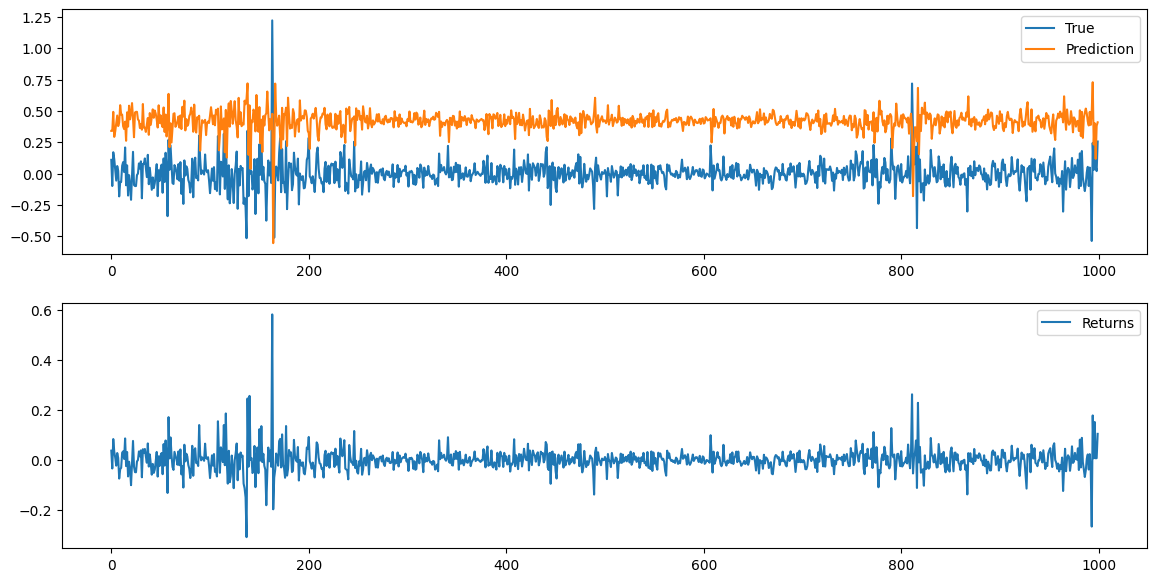

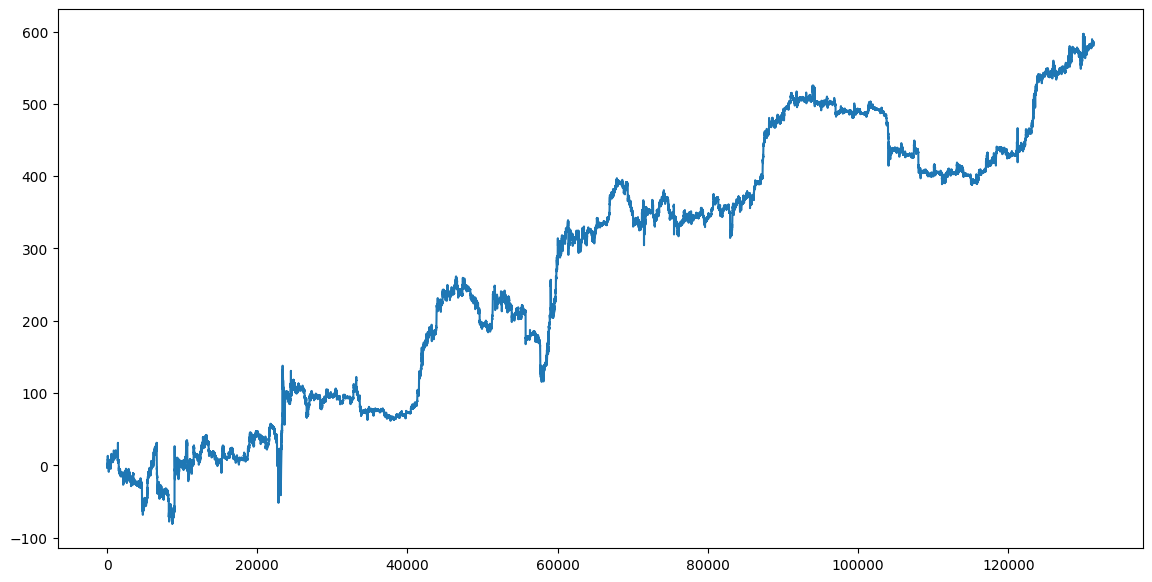

##### TRAIN socre 1.3672E-02 norm 1.6607E-01 r: 2.2705E-03 VALIDATION score 4.4581E-03 norm 8.6133E-02 r: 3.8399E-04 #####


  0%|          | 0/2053 [00:00<?, ?batch/s]

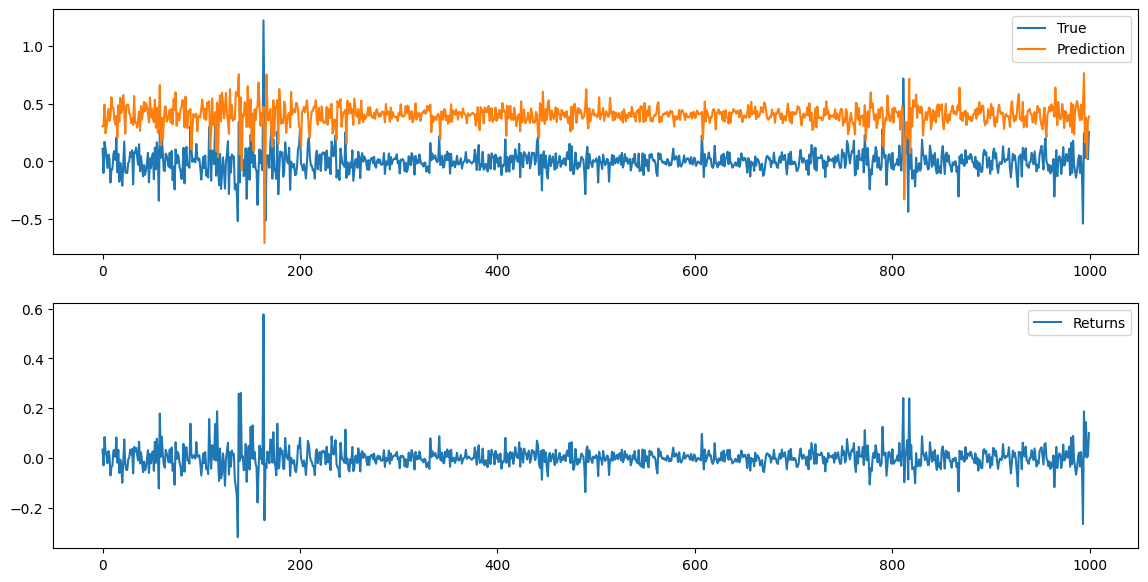

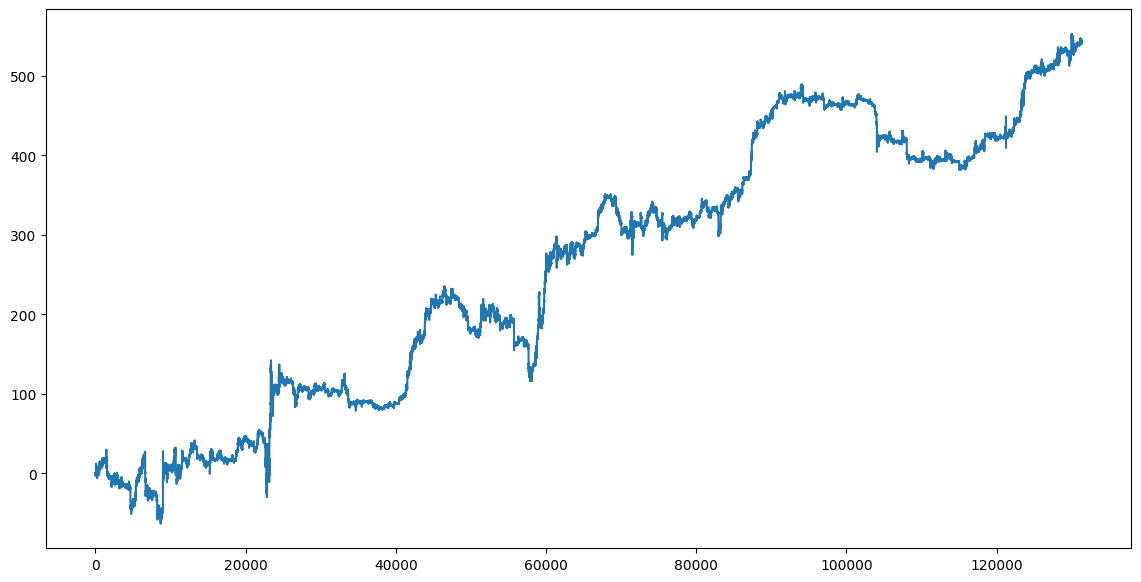

##### TRAIN socre 1.2986E-02 norm 2.0086E-01 r: 2.6084E-03 VALIDATION score 4.1444E-03 norm 1.0570E-01 r: 4.3807E-04 #####


  0%|          | 0/2053 [00:00<?, ?batch/s]

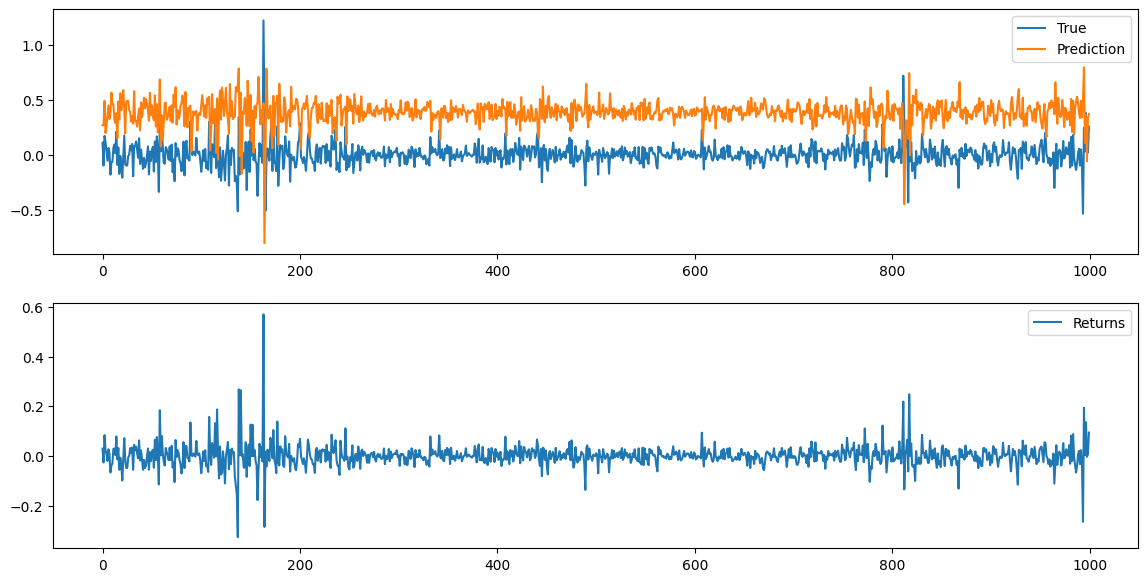

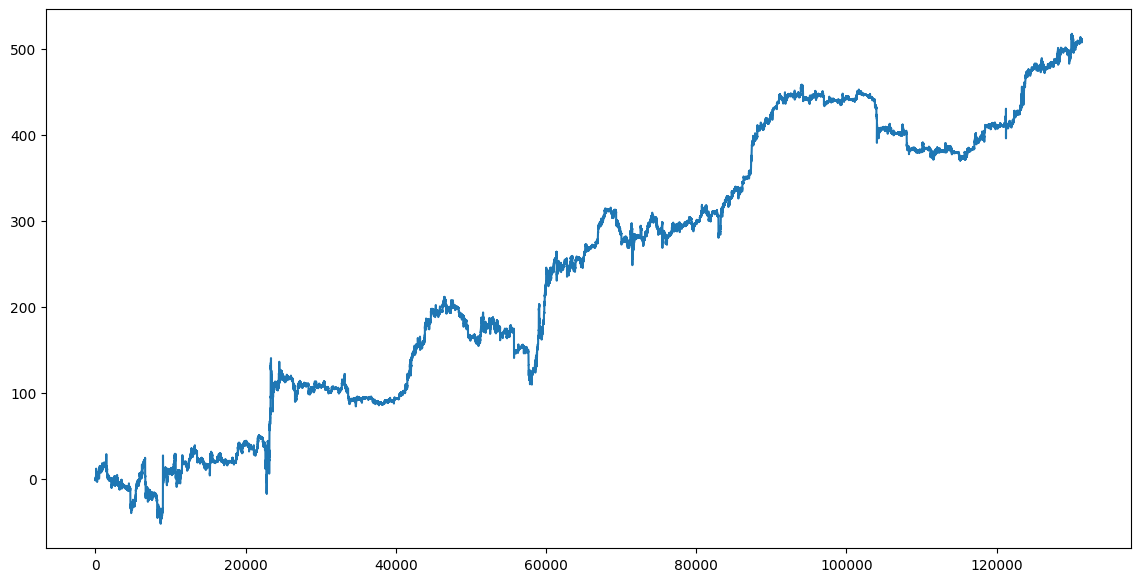

##### TRAIN socre 1.2448E-02 norm 2.3187E-01 r: 2.8864E-03 VALIDATION score 3.8923E-03 norm 1.2374E-01 r: 4.8162E-04 #####


  0%|          | 0/2053 [00:00<?, ?batch/s]

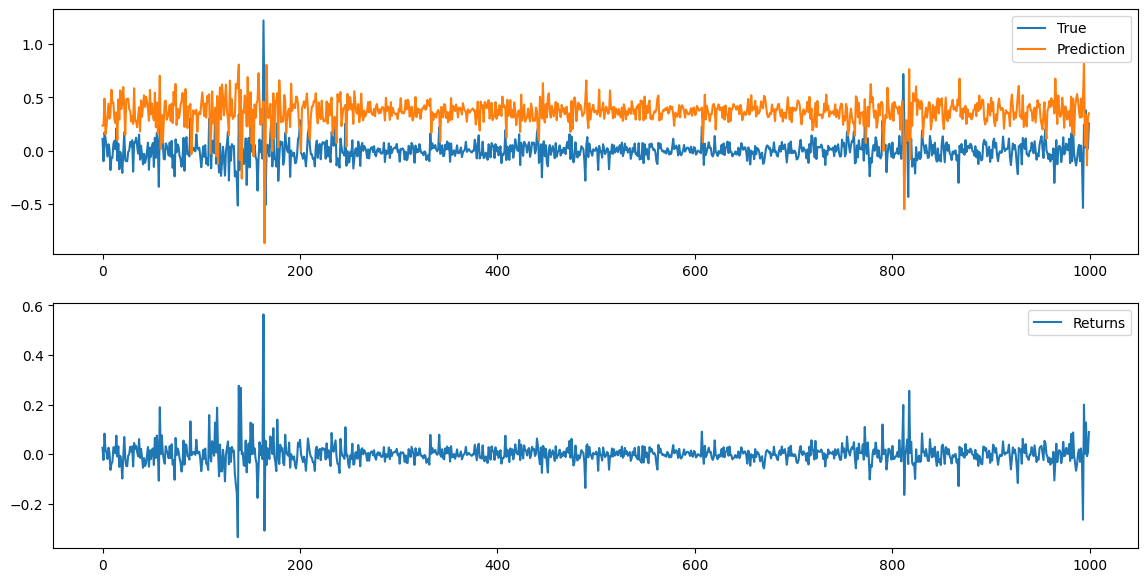

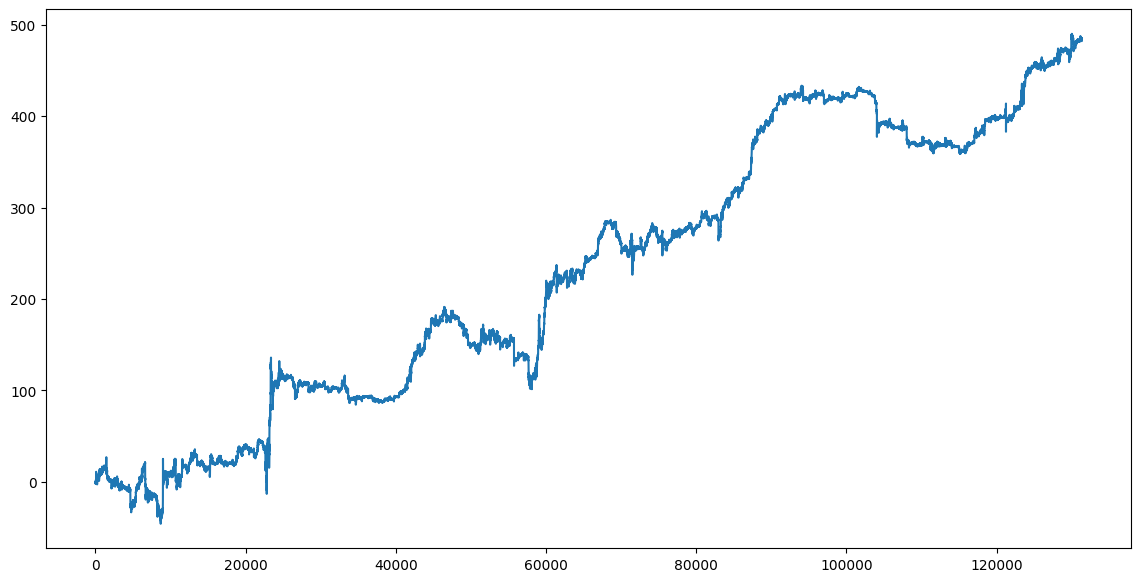

##### TRAIN socre 1.2021E-02 norm 2.5911E-01 r: 3.1148E-03 VALIDATION score 3.6924E-03 norm 1.4006E-01 r: 5.1716E-04 #####


  0%|          | 0/2053 [00:00<?, ?batch/s]

KeyboardInterrupt: 

In [42]:
epoch = tqdm(range(config.num_epochs), unit='epoch')

for e in epoch:
    model.train()
    loss = run_epoch(
        model, train_dataloader, optimizer, criterion)

    model.eval()

    train_history.append(eval_epoch(model, train_dataloader_infer))

    val_history.append(eval_epoch(model, val_dataloader, points=1000))
    

    print('##### TRAIN socre {:.4E} norm {:.4E} r: {:.4E} VALIDATION score {:.4E} norm {:.4E} r: {:.4E} #####'.format(*train_history[-1], *val_history[-1]))

    # epoch.set_description(
    #     '##### Train SCOREdata.shape[1] {:.4E}  Validation SCORE {:.4E}  #####'.format(train_score, validation_score))

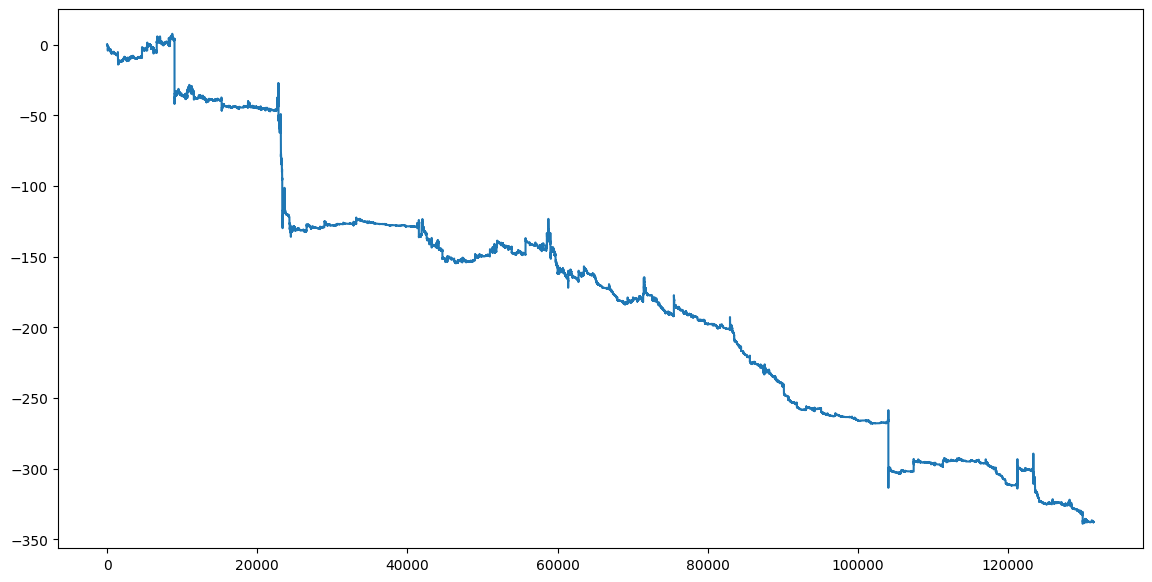

In [23]:
rtest = (test_target[:-1] * test_data[1:])

plt.figure(figsize=(14, 7))
plt.plot(np.cumsum(rtest), label='True')

5.618632954070169e-18


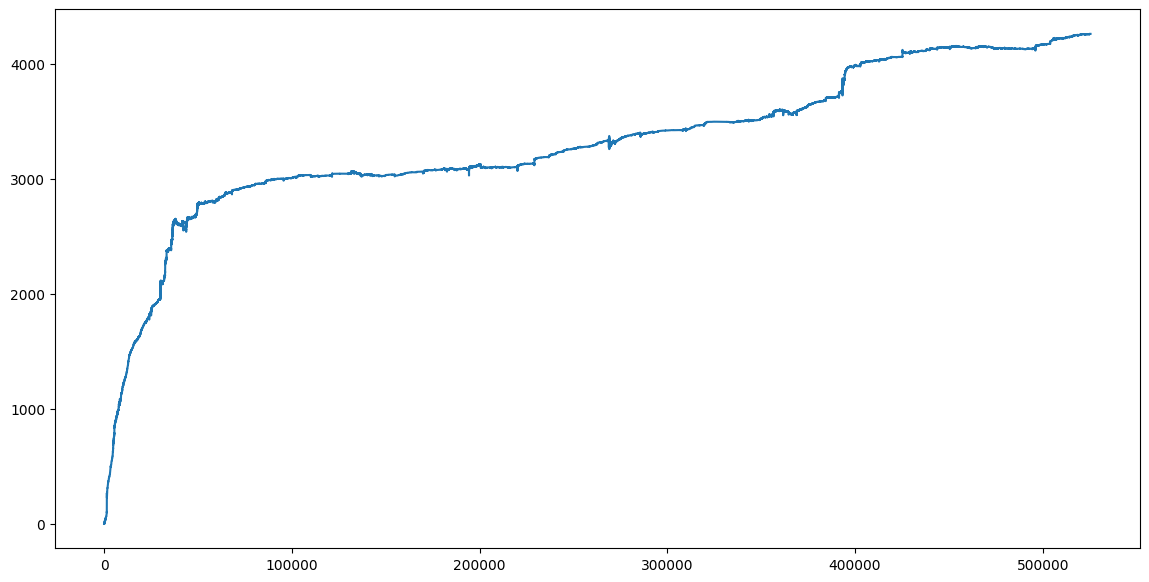

In [22]:
r = (train_data[:-1] * -0.5)* train_target[1:]


print(train_target.mean())

rcm = np.cumsum(r)

plt.figure(figsize=(14, 7))
plt.plot(rcm)

##### LSTM 10 epoch TRAIN mse 9.9804E-01 mae 9.9112E-01 r: 0.0000E+00 VALIDATION mse 1.0025E+00 mae 9.9044E-01 r: 0.0000E+00 #####
##### CNN TRAIN mse 9.9705E-01 mae 9.9150E-01 r: 0.0000E+00 VALIDATION mse 1.0021E+00 mae 9.9299E-01 r: 0.0000E+00 #####

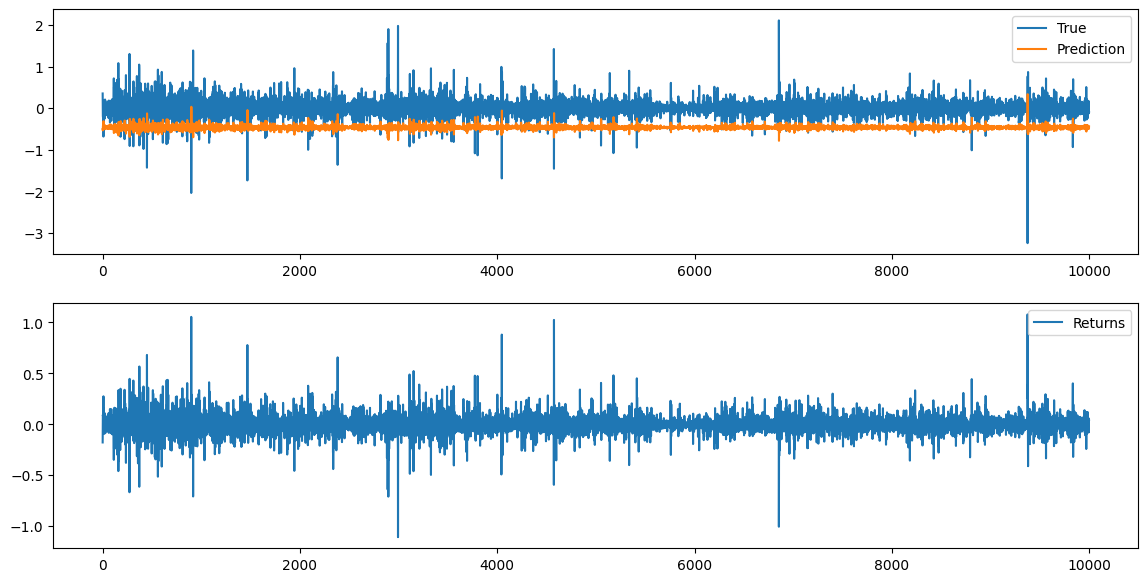

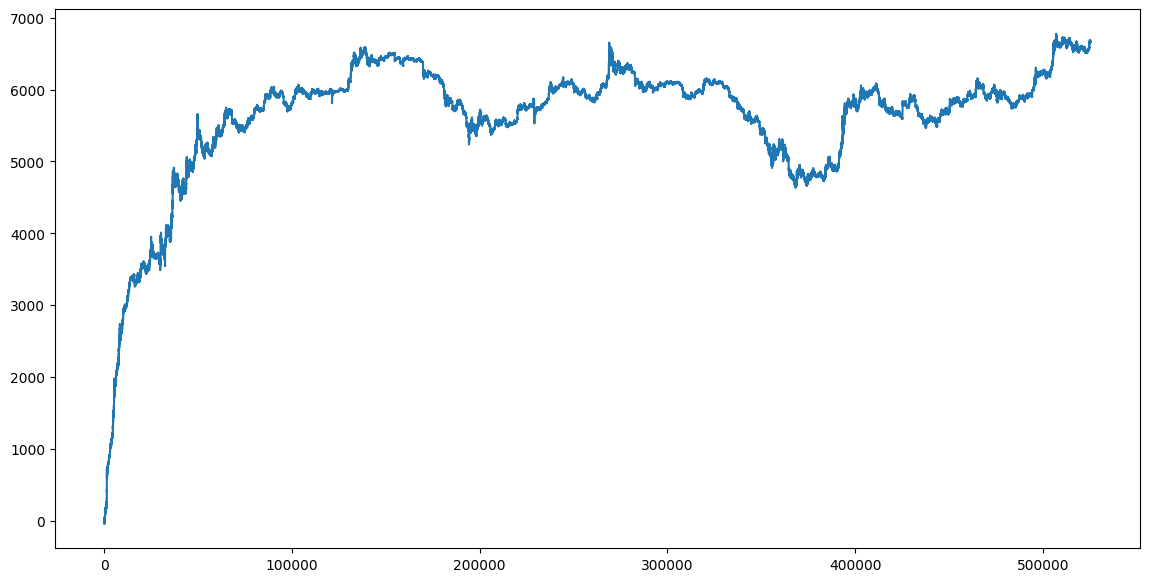

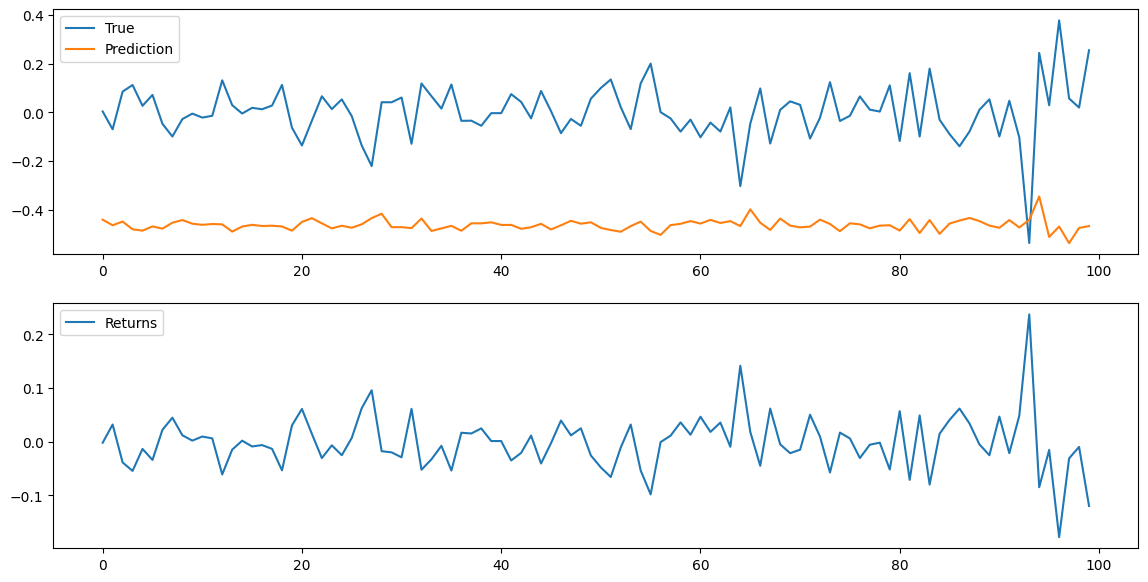

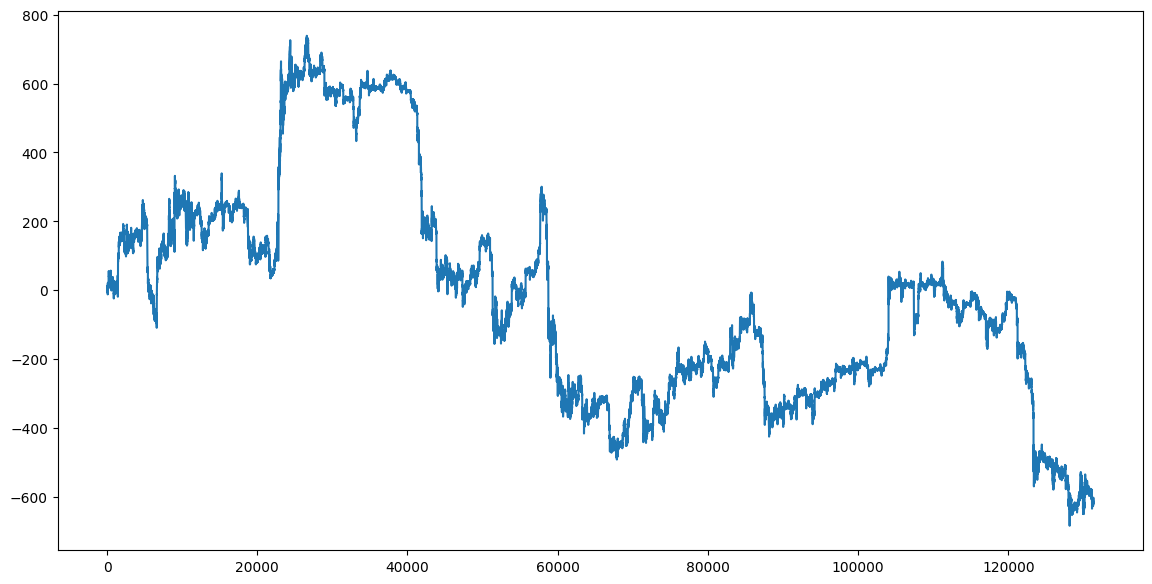

##### TRAIN mse 1.2673E-02 mae 5.0000E-02 r: 6.3365E-04 VALIDATION mse -4.7243E-03 mae 2.5029E-02 r: -1.1824E-04 #####


In [ ]:

print('##### TRAIN mse {:.4E} mae {:.4E} r: {:.4E} VALIDATION mse {:.4E} mae {:.4E} r: {:.4E} #####'.format(*eval_epoch(model, train_dataloader_infer, points=10000), *eval_epoch(model, val_dataloader, points=100)))
